In [26]:
#Importation des bibliotheques
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


In [27]:
#Chargement 
wine=datasets.load_wine()
X=pd.DataFrame(wine.data,columns=wine.feature_names)
Y=pd.Series(wine.target,name="classe")
X.head(),Y.head()


(   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
 0    14.23        1.71  2.43               15.6      127.0           2.80   
 1    13.20        1.78  2.14               11.2      100.0           2.65   
 2    13.16        2.36  2.67               18.6      101.0           2.80   
 3    14.37        1.95  2.50               16.8      113.0           3.85   
 4    13.24        2.59  2.87               21.0      118.0           2.80   
 
    flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
 0        3.06                  0.28             2.29             5.64  1.04   
 1        2.76                  0.26             1.28             4.38  1.05   
 2        3.24                  0.30             2.81             5.68  1.03   
 3        3.49                  0.24             2.18             7.80  0.86   
 4        2.69                  0.39             1.82             4.32  1.04   
 
    od280/od315_of_diluted_wines  proline  
 0  

In [28]:
#Exploaration
X.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [29]:
(X_train,X_test,Y_train,Y_test)=train_test_split(X,Y,test_size=0.2) #Separation test/train
scaler=StandardScaler() #Normalisation
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [30]:
#Entrainer le modele
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,Y_train)
#Predire les classes de X_test
Y_pred=knn.predict(X_test_scaled)


Accuracy: 0.9722222222222222
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.93      0.96        14
           2       0.89      1.00      0.94         8

    accuracy                           0.97        36
   macro avg       0.96      0.98      0.97        36
weighted avg       0.98      0.97      0.97        36



Text(0.5, 1.0, 'Matrice de confusion')

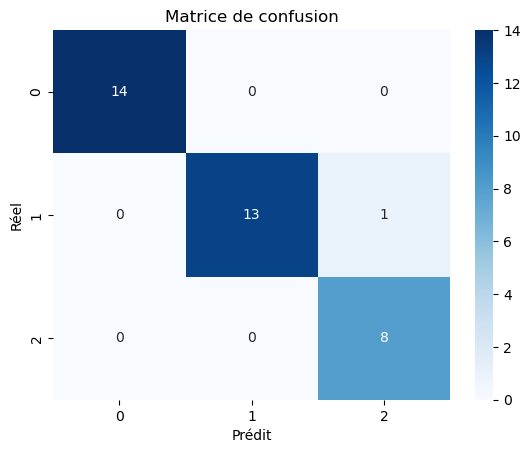

In [33]:
#Evaluation
print("Accuracy:",accuracy_score(Y_test,Y_pred))
print("Classification report:")
print(classification_report(Y_test,Y_pred))
cm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cm,annot=True,cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")


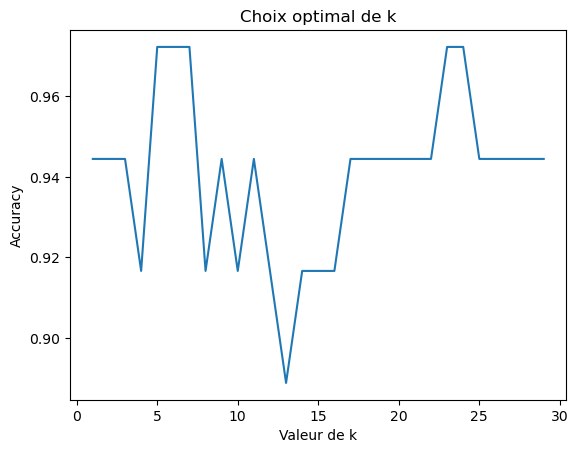

In [37]:
#Etude du paramètre k 
k_values=range(1,30)
accuracies=[]
for k in k_values:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled,Y_train)
    Y_pred=model.predict(X_test_scaled)
    score=accuracy_score(Y_test,Y_pred)
    accuracies.append(score)
plt.plot(k_values,accuracies)
plt.xlabel("Valeur de k")
plt.ylabel("Accuracy")
plt.title("Choix optimal de k")
plt.savefig("graph.png")
plt.show()
    
    

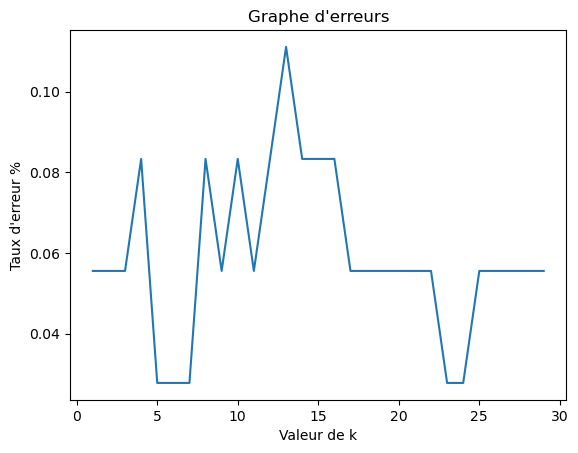

In [39]:
erreurs=[1-acc for acc in accuracies]
plt.plot(k_values,erreurs)
plt.xlabel("Valeur de k")
plt.ylabel("Taux d'erreur %")
plt.title("Graphe d'erreurs")
plt.show()
#l'erreur augmente a partir de la valeur 3 a peu pres"
#k=5 semble optimal
